# Формула цифрового счастья
## Анализ эмоционального фона ВКонтакте с помощью ML и Deep Learning

Выполнили: Дарья Сечкина и Валерия Нам, ПАДИИ 2 курс  

### Структура ноутбука

| № | Раздел |
|---|--------|
| 1 | Постановка задачи |
| 2 | Загрузка и описание данных (2 датасета) |
| 3 | Разведочный анализ данных (EDA) |
| 4 | Предобработка текстов |
| 5 | Baseline: TF-IDF + Logistic Regression |
| 6 | TF-IDF + LinearSVC + кросс-валидация |
| 7 | Deep Learning: RuBERT (zero-shot inference) |
| 8 | Сравнение моделей: количественный и качественный анализ |
| 9 | Применение лучшей модели к постам ВКонтакте |
| 10 | Расчёт Индекса цифрового счастья |
| 11 | Сегментированный анализ и визуализация |
| 12 | Выводы и ограничения |

## 1. Постановка задачи

**Цель:** разработать метрику **Happiness Index** — количественную оценку цифрового благополучия пользователей ВКонтакте на основе открытого цифрового следа (тексты постов, паттерны активности, социальные связи) без прямого анкетирования.

**ML-задача:** трёхклассовая классификация тональности текста (`негативный / позитивный / нейтральный`) для оценки эмоционального фона пользовательского контента.

**Формула Индекса счастья:**

$$\text{Happiness_Index} = 0.30 \cdot S_{\text{network}} + 0.20 \cdot S_{\text{activity}} + 0.50 \cdot S_{\text{sentiment}}$$

| Компонент | Признак | Вес | Обоснование |
|-----------|---------|-----|-------------|
| $S_{\text{network}}$ | Кол-во друзей| 0.30 | Социальные связи коррелируют с субъективным благополучием
| $S_{\text{activity}}$ | Посты + репосты | 0.20 | Вовлечённость в платформу как показатель социальной активности |
| $S_{\text{sentiment}}$ | Доля позитивных постов | 0.50 | Ключевой показатель: эмоциональный фон контента (наибольший вес) |

При выявлении негативных паттернов к базовому индексу применяются **штрафные корректировки**:
* **Токсичность:** наличие депрессивных/токсичных сообществ (штрафной коэффициент `×0.85`).
* **Эффект витрины / Коммерция:** если подписчиков в 5+ раз больше, чем друзей, то это означает, что аккаунт используется для коммерции, а не для социализации (штрафной коэффициент `×0.90`).
* **Индекс бессонницы:** регулярная публикация постов в ночное время (01:00–05:00) коррелирует с тревожностью. Применяется линейный вычет пропорционально доле ночных постов (до `-0.15`).

Все компоненты нормированы в диапазоне [0, 1].

**Основная метрика оценки моделей:** weighted F1-score — учитывает баланс классов и применима к трёхклассовой задаче.

**Этический протокол:** данные собраны только из публичных профилей (is_closed: False); в итоговом датасете пользователи представлены обезличенными ID; личные сообщения и закрытые данные не запрашивались.

### Установка зависимостей

In [4]:
!pip install datasets transformers torch scikit-learn seaborn matplotlib pandas tqdm

## Импорты и конфигурация

In [23]:
import json
import re
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from datasets import load_dataset
from transformers import pipeline as hf_pipeline
import torch
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
sns.set_theme(style="whitegrid", palette="pastel")
RANDOM_STATE = 42
DEVICE = 0 if torch.cuda.is_available() else -1
TARGET_NAMES = ['Негативный', 'Позитивный', 'Нейтральный']
LABEL2NAME = {0: 'Негативный', 1: 'Позитивный', 2: 'Нейтральный'}
TOXIC_KEYWORDS = ['депрессия', 'грусть', 'боль', 'слезы', 'одиночество', 'апатия', 'ненависть', 'суицид', 'смерть', 'безысходность']
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} | Device: {'GPU' if DEVICE == 0 else 'CPU'}")

PyTorch: 2.11.0+cu128
CUDA available: True | Device: GPU


## 2. Загрузка и описание данных

Проект использует **два датасета** из открытых источников:

| # | Датасет | Источник | Размер | Описание |
|---|---------|----------|--------|----------|
| 1 | `data.json` | VK API (собственный сбор) | ~743 профилей | Пользователи 18–35 лет, 7 городов РФ |
| 2 | `k1tub/sentiment_dataset` | [HuggingFace Datasets](https://huggingface.co/datasets/k1tub/sentiment_dataset) | 290 458 текстов | Русскоязычный корпус тональности |

### Датасет 1: Пользователи ВКонтакте (`data.json`)

Собран через VK API из публичных профилей (is_closed: False). Включает тексты постов, социальные метрики и данные об участии в сообществах.

In [6]:
with open('data.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

users_list = []
posts_list = []

for u in raw_data:
    age = u.get('age', 0)
    friends_num = u.get('friends_num', 0)

    if not (18 <= age <= 35 and 0 < friends_num < 5000 and u.get('self_posts_num', 0) > 0):
        continue

    groups = u.get('groups', {})
    groups_text = ' '.join(f"{g.get('name','')} {g.get('description','')}" for g in groups.values()).lower()
    has_toxic = any(kw in groups_text for kw in TOXIC_KEYWORDS)

    night_posts = 0
    valid_posts = 0

    for post_id, post_data in u.get('posts', {}).items():
        text = post_data.get('text', '').strip()
        date_str = post_data.get('date', '')

        if len(text) > 15:
            posts_list.append({'user_id': u['id'], 'post_id': post_id, 'text': text})
            valid_posts += 1

            try:
                hour = int(date_str.split(' ')[1].split(':')[0])
                if 1 <= hour <= 5:
                    night_posts += 1
            except:
                pass

    night_ratio = night_posts / valid_posts if valid_posts > 0 else 0

    users_list.append({
        'user_id': u['id'],
        'city': u.get('city', 'Неизвестно'),
        'age': age,
        'gender': u.get('gender', 'Не указан'),
        'friends_num': friends_num,
        'followers_num': u.get('followers_num', 0),
        'groups_num': u.get('groups_num', 0),
        'self_posts_num': u.get('self_posts_num', 0),
        'reposts_num': u.get('reposts_num', 0),
        'has_toxic_groups': has_toxic,
        'night_posts_ratio': night_ratio,
        'groups_text': groups_text
    })

users_df = pd.DataFrame(users_list)
posts_df = pd.DataFrame(posts_list)

print(f"Пользователей после фильтрации: {len(users_df)}")
print(f"Постов для анализа: {len(posts_df)}")
print(f"Средняя доля ночных постов: {users_df['night_posts_ratio'].mean():.2%}")
users_df.head()

Пользователей после фильтрации: 572
Постов для анализа: 15987
Средняя доля ночных постов: 8.94%


,user_id,city,age,gender,friends_num,followers_num,groups_num,self_posts_num,reposts_num,has_toxic_groups,night_posts_ratio,groups_text
0,230173495,Москва,33,female,249,0,57,11,89,True,0.333333,мяч и шайба мяч и шайба: футбол и хоккей 24/7\...
1,33545305,Москва,30,female,371,0,16,58,42,True,0.041667,анастасия тарасова (костенко) № 4840332313 дми...
2,104916144,Москва,25,female,1862,0,699,98,2,True,0.000000,сводки от ополчения новороссии добровольный до...
3,641099221,Москва,31,male,1849,0,53,91,9,True,0.000000,народный фронт народный фронт — общественное д...
4,15087000,Москва,31,male,2761,0,87,83,17,True,0.093333,газета.ru страница ведущего общественно-полити...


In [7]:
print("Базовая статистика — датасет VK (Датасет 1):")
users_df[['age', 'friends_num', 'groups_num', 'self_posts_num', 'reposts_num']].describe().round(1)

Базовая статистика — датасет VK (Датасет 1):


,age,friends_num,groups_num,self_posts_num,reposts_num
count,572.0,572.0,572.0,572.0,572.0
mean,29.4,857.0,196.7,52.2,16.1
std,4.0,1212.6,261.5,37.1,24.2
min,18.0,1.0,0.0,1.0,0.0
25%,27.0,118.8,27.0,15.0,0.0
50%,30.0,295.0,91.5,51.0,4.0
75%,33.0,889.8,240.2,92.2,22.0
max,35.0,4967.0,996.0,100.0,99.0


### Датасет 2: Русскоязычный корпус тональности (HuggingFace)

**`k1tub/sentiment_dataset`** — публичный корпус для задачи анализа тональности русскоязычных текстов из разных источников: отзывы на товары, комментарии, посты в социальных сетях.

**Разметка:** `0` — негативный, `1` — позитивный, `2` — нейтральный  
**Источник:** https://huggingface.co/datasets/k1tub/sentiment_dataset

In [8]:
dataset = load_dataset("k1tub/sentiment_dataset")
df_sent = dataset['train'].to_pandas()
print(f"Всего записей в датасете: {len(df_sent):,}")
print(f"Распределение меток: {df_sent['label'].value_counts().sort_index().to_dict()}")
print(f"Источники текстов: {df_sent['src'].unique() if 'src' in df_sent.columns else 'n/a'}")
print("\nПримеры:")
for label, name in [(0, 'Негативный'), (1, 'Позитивный'), (2, 'Нейтральный')]:
    ex = df_sent[df_sent['label']==label]['text'].iloc[0]
    print(f"[{name}] {ex[:100]}...")

README.md:   0%|          | 0.00/3.02k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/96.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/290458 [00:00<?, ? examples/s]

Всего записей в датасете: 290,458
Распределение меток: {0: 96589, 1: 96877, 2: 96992}
Источники текстов: ['rureviews' 'anime' 'geo' 'sber' 'bank' 'rusentiment' 'kinopoisk' 'linis'
 'news' 'ru-reviews-classification' 'perekrestok']

Примеры:
[Негативный] Пальто красивое, но пришло с дырой в молнии. Просила выслать такую же, но продавец настаивал на откр...
[Позитивный] отличная рубашка. на размер 46- 48 брала xxl...
[Нейтральный] Продавец отправил посылку на неверный адрес, пол месяца кормил завтраками что отправит повторно, но ...


In [9]:
df_sample = df_sent[df_sent['label'].isin([0, 1, 2])].copy()
df_sample = df_sample.groupby('label', group_keys=False).apply(lambda x: x.sample(min(len(x), 2500), random_state=RANDOM_STATE)).reset_index(drop=True)
print(f"Итого для обучения/тестирования: {len(df_sample)} примеров")
print(f"Баланс классов: {df_sample['label'].value_counts().sort_index().to_dict()}")
print("Сбалансированный датасет обеспечивает честное сравнение моделей")

Итого для обучения/тестирования: 7500 примеров
Баланс классов: {0: 2500, 1: 2500, 2: 2500}
Сбалансированный датасет обеспечивает честное сравнение моделей


## 3. Разведочный анализ данных (EDA)

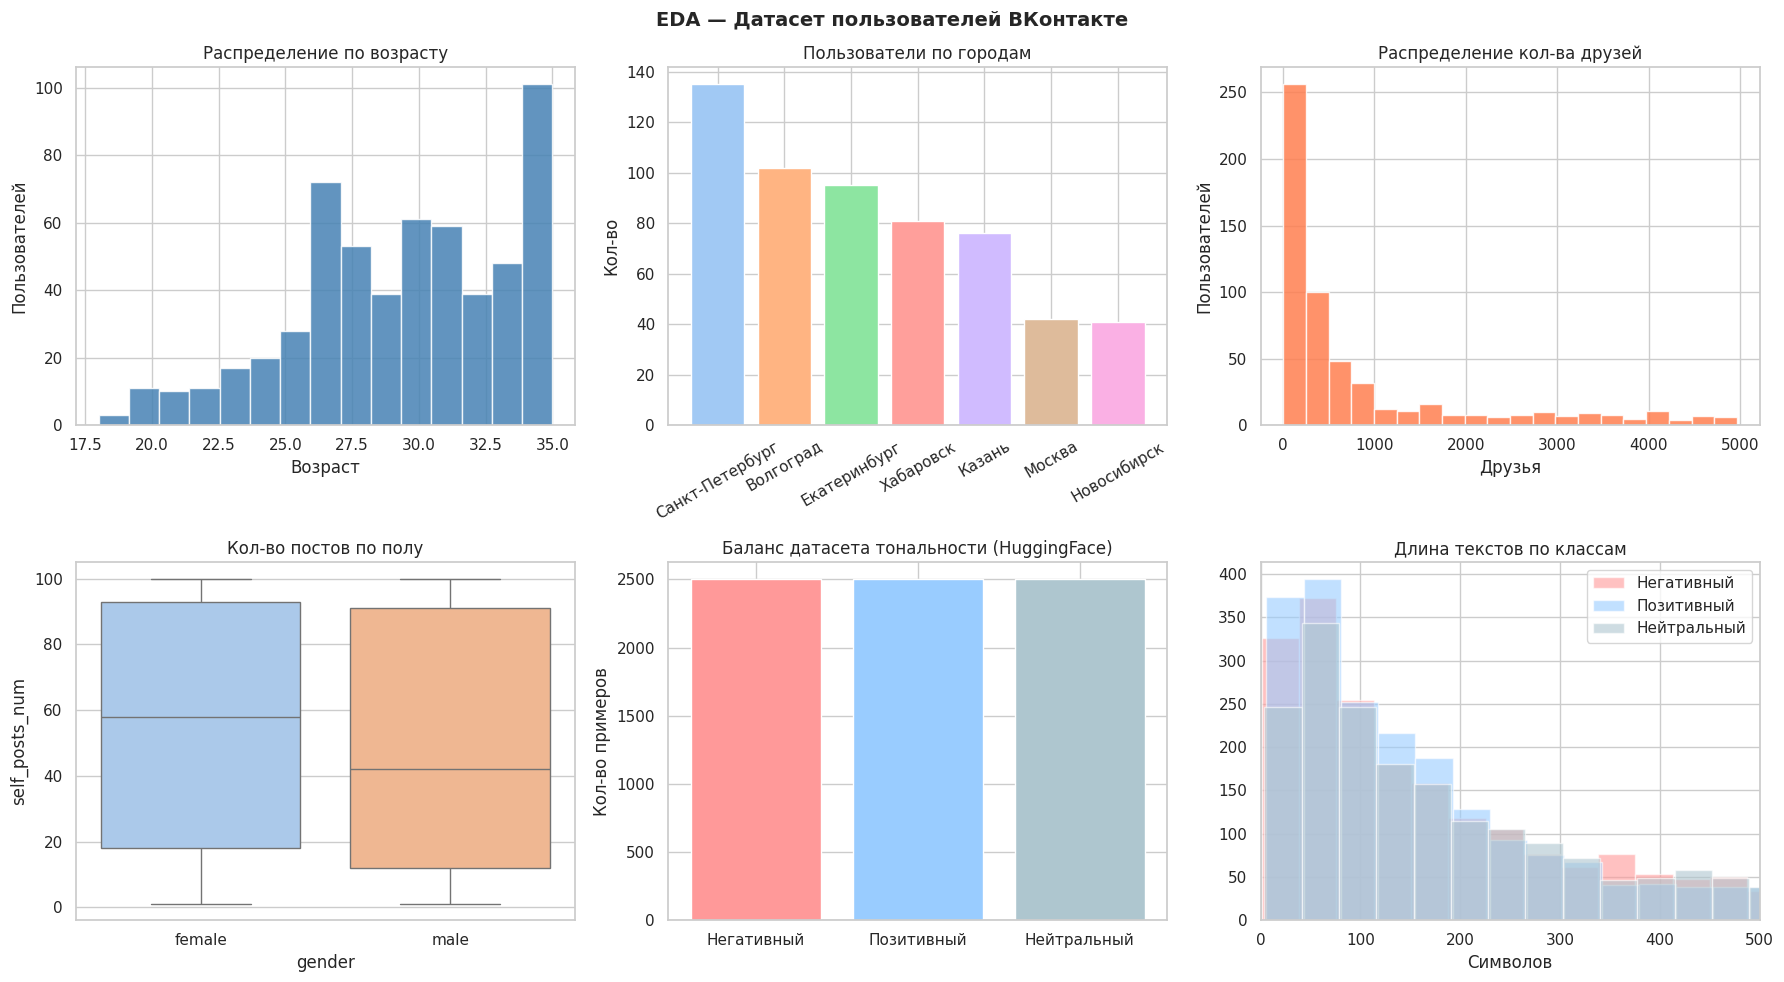

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Датасет пользователей ВКонтакте', fontsize=14, fontweight='bold')
axes[0,0].hist(users_df['age'], bins=15, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Распределение по возрасту')
axes[0,0].set_xlabel('Возраст'); axes[0,0].set_ylabel('Пользователей')
city_counts = users_df['city'].value_counts()
axes[0,1].bar(city_counts.index, city_counts.values, color=sns.color_palette('pastel', len(city_counts)), edgecolor='white')
axes[0,1].set_title('Пользователи по городам')
axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].set_ylabel('Кол-во')
axes[0,2].hist(users_df['friends_num'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Распределение кол-ва друзей')
axes[0,2].set_xlabel('Друзья'); axes[0,2].set_ylabel('Пользователей')
sns.boxplot(x='gender', y='self_posts_num', data=users_df, ax=axes[1,0], palette='pastel', hue='gender', legend=False)
axes[1,0].set_title('Кол-во постов по полу')
label_counts = df_sample['label'].value_counts().sort_index()
axes[1,1].bar(TARGET_NAMES, label_counts.values, color=['#ff9999', '#99ccff', '#aec6cf'], edgecolor='white')
axes[1,1].set_title('Баланс датасета тональности (HuggingFace)')
axes[1,1].set_ylabel('Кол-во примеров')
df_sample['text_len'] = df_sample['text'].str.len()
for label, color, name in zip([0,1,2], ['#ff9999','#99ccff','#aec6cf'], TARGET_NAMES):
    axes[1,2].hist(df_sample[df_sample['label']==label]['text_len'],
                   bins=40, alpha=0.6, color=color, label=name)
axes[1,2].set_title('Длина текстов по классам')
axes[1,2].set_xlabel('Символов'); axes[1,2].legend(); axes[1,2].set_xlim(0, 500)
plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Предобработка текстов

Перед обучением ML-моделей выполняется очистка текстов: удаление URL, HTML-тегов, лишних пробелов. Это улучшает качество TF-IDF векторизации.

 Для RuBERT предобработка не требуется — трансформеры обрабатывают сырой текст, включая эмодзи и знаки препинания.

In [11]:
def clean_text(text: str) -> str:
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^а-яёА-ЯЁa-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()
df_sample['text_clean'] = df_sample['text'].apply(clean_text)
print("Примеры очистки:")
for i in range(3):
    orig = df_sample['text'].iloc[i]
    clean = df_sample['text_clean'].iloc[i]
    print(f"Исходный: {orig[:100]}")
    print(f"Очищенный: {clean[:100]}")
    print()

Примеры очистки:
Исходный: Рассыпается на мелкие кусочки , когда в охлажденном , до 4 градусов, виде. не понравилось.
Очищенный: рассыпается на мелкие кусочки когда в охлажденном до 4 градусов виде не понравилось

Исходный: Были в данном заведении в середине апреля. В целом - неплохое место для завтрака на любой вкус. \n\n
Очищенный: были в данном заведении в середине апреля в целом неплохое место для завтрака на любой вкус n nчто п

Исходный: Заказала 11 сентября, пришли уже 25, цвет отличается от того что на фото
Очищенный: заказала 11 сентября пришли уже 25 цвет отличается от того что на фото



## 5. Baseline: TF-IDF + Logistic Regression (MVP)

Начинаем с простейшего подхода — это наш MVP.

**Обоснование выбора:**
- TF-IDF + Logistic Regression — стандартный baseline для текстовой классификации
- Быстро обучается, легко интерпретируем
- Служит нижней границей для оценки более сложных методов

**Известные ограничения:**
- Не учитывает порядок слов и контекст
- Плохо справляется со сленгом, иронией, отрицанием
- Нейтральный класс труден — нет ярко выраженных ключевых слов

Train: 6000 | Test: 1500
TF-IDF матрица: (6000, 20000)

TF-IDF + Logistic Regression (MVP)
              precision    recall  f1-score   support

  Негативный       0.51      0.52      0.52       500
  Позитивный       0.72      0.70      0.71       500
 Нейтральный       0.62      0.63      0.63       500

    accuracy                           0.62      1500
   macro avg       0.62      0.62      0.62      1500
weighted avg       0.62      0.62      0.62      1500



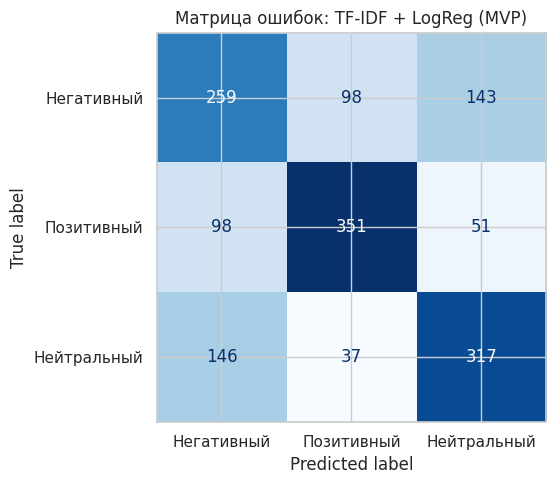

In [12]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df_sample['text'].tolist(),
    df_sample['label'].tolist(),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_sample['label'].tolist())
X_train_clean = [clean_text(t) for t in X_train_raw]
X_test_clean = [clean_text(t) for t in X_test_raw]
print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")
vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True, min_df=3)
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)
print(f"TF-IDF матрица: {X_train_vec.shape}")
logreg = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE, class_weight='balanced')
logreg.fit(X_train_vec, y_train)
logreg_preds = logreg.predict(X_test_vec)
logreg_f1 = f1_score(y_test, logreg_preds, average='weighted')
print("\nTF-IDF + Logistic Regression (MVP)")
print(classification_report(y_test, logreg_preds, target_names=TARGET_NAMES))
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, logreg_preds)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Матрица ошибок: TF-IDF + LogReg (MVP)')
plt.tight_layout()
plt.savefig('cm_logreg.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. TF-IDF + LinearSVC

**Обоснование выбора LinearSVC:**
- На задачах с большим словарём LinearSVC теоретически конкурентоспособен с Logistic Regression
- Эффективно работает с разреженными матрицами (TF-IDF)
- Биграммы учитывают устойчивые словосочетания типа «не нравится», «очень хорошо»

### Кросс-валидация для обеих ML-моделей

Для получения устойчивых оценок применяется 5-кратная стратифицированная кросс-валидация.

In [24]:
svc = LinearSVC(max_iter=2000, C=0.5, random_state=RANDOM_STATE, class_weight='balanced')
svc.fit(X_train_vec, y_train)
svc_preds = svc.predict(X_test_vec)
svc_f1 = f1_score(y_test, svc_preds, average='weighted')

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_preds = nb.predict(X_test_vec)
nb_f1 = f1_score(y_test, nb_preds, average='weighted')

rf = RandomForestClassifier(n_estimators=100, max_depth=50, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_vec, y_train)
rf_preds = rf.predict(X_test_vec)
rf_f1 = f1_score(y_test, rf_preds, average='weighted')

print("LinearSVC F1:       ", round(svc_f1, 3))
print("Naive Bayes F1:     ", round(nb_f1, 3))
print("Random Forest F1:   ", round(rf_f1, 3))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_clean = [clean_text(t) for t in df_sample['text'].tolist()]
X_all_vec = vectorizer.transform(X_all_clean)
y_all = df_sample['label'].tolist()

cv_logreg = cross_val_score(logreg, X_all_vec, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)
cv_svc    = cross_val_score(svc,    X_all_vec, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)
cv_nb     = cross_val_score(nb,     X_all_vec, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)
cv_rf     = cross_val_score(rf,     X_all_vec, y_all, cv=skf, scoring='f1_weighted', n_jobs=-1)

print("Результаты CV (weighted F1):")
print(f"TF-IDF + LogReg:        {cv_logreg.mean():.4f} ± {cv_logreg.std():.4f}")
print(f"TF-IDF + LinearSVC:     {cv_svc.mean():.4f} ± {cv_svc.std():.4f}")
print(f"TF-IDF + Naive Bayes:   {cv_nb.mean():.4f} ± {cv_nb.std():.4f}")
print(f"TF-IDF + Random Forest: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

LinearSVC F1:        0.609
Naive Bayes F1:      0.613
Random Forest F1:    0.579

--- Запуск 5-кратной кросс-валидации (CV) для всех ML-моделей ---
Результаты CV (weighted F1):
TF-IDF + LogReg:        0.6286 ± 0.0149
TF-IDF + LinearSVC:     0.6193 ± 0.0161
TF-IDF + Naive Bayes:   0.6281 ± 0.0099
TF-IDF + Random Forest: 0.5996 ± 0.0081


## 7. Deep Learning: RuBERT (zero-shot inference)

**Модель:** [`blanchefort/rubert-base-cased-sentiment`](https://huggingface.co/blanchefort/rubert-base-cased-sentiment)  
RuBERT - это трансформер, предобученный на русскоязычных текстах и дообученный для задачи анализа тональности.

**Обоснование выбора:**
- Трёхклассовая модель (POSITIVE / NEUTRAL / NEGATIVE) соответствует постановке задачи
- Контекстные эмбеддинги: понимает морфологию русского языка, сленг, иронию, отрицание
- Предобучена на >1 млрд токенов
- Архитектура BERT учитывает двусторонний контекст каждого слова

Без дообучения на нашем датасете.
TF-IDF-модели обучены на том же датасете, RuBERT — нет.

config.json:   0%|          | 0.00/943 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/499 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


RuBERT (Deep Learning, zero-shot)
              precision    recall  f1-score   support

  Негативный       0.27      0.31      0.29       500
  Позитивный       0.69      0.69      0.69       500
 Нейтральный       0.25      0.21      0.23       500

    accuracy                           0.41      1500
   macro avg       0.40      0.41      0.40      1500
weighted avg       0.40      0.41      0.40      1500



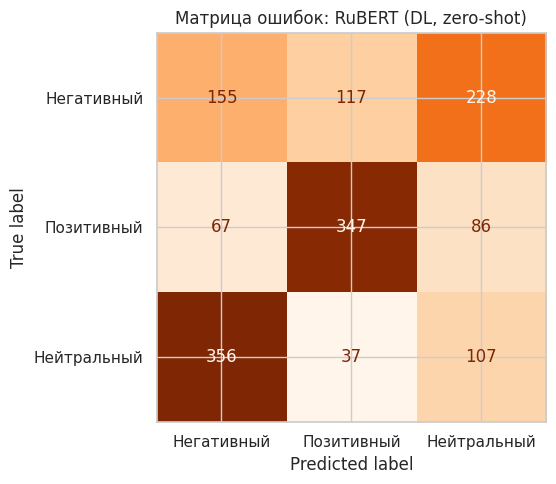

In [15]:
sentiment_pipe = hf_pipeline(
    "sentiment-analysis",
    model="blanchefort/rubert-base-cased-sentiment",
    device=DEVICE,
    truncation=True,
    max_length=512)
def rubert_label(r: dict) -> int:
    if r['label'] == 'POSITIVE': return 1
    elif r['label'] == 'NEGATIVE': return 0
    else: return 2
dl_preds_raw = sentiment_pipe(X_test_raw, batch_size=32)
dl_preds = [rubert_label(r) for r in dl_preds_raw]
dl_f1 = f1_score(y_test, dl_preds, average='weighted')
print("\nRuBERT (Deep Learning, zero-shot)")
print(classification_report(y_test, dl_preds, target_names=TARGET_NAMES))
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, dl_preds)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Матрица ошибок: RuBERT (DL, zero-shot)')
plt.tight_layout()
plt.savefig('cm_dl.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Сравнение моделей: количественный и качественный анализ

### 8.1 Количественное сравнение

Итоговая таблица сравнения моделей:
                Модель                          Тип  F1-weighted  Accuracy  CV F1 (mean)  CV F1 (±std)
 TF-IDF + LogReg (MVP)      Classical ML (Линейная)     0.618507  0.618000      0.628624      0.014858
  TF-IDF + Naive Bayes Classical ML (Вероятностная)     0.613131  0.611333      0.628070      0.009918
    TF-IDF + LinearSVC      Classical ML (Линейная)     0.608548  0.608667      0.619337      0.016057
TF-IDF + Random Forest      Classical ML (Ансамбль)     0.578598  0.579333      0.599618      0.008071
RuBERT (DL, zero-shot)  Deep Learning (Трансформер)     0.404411  0.406000           NaN           NaN


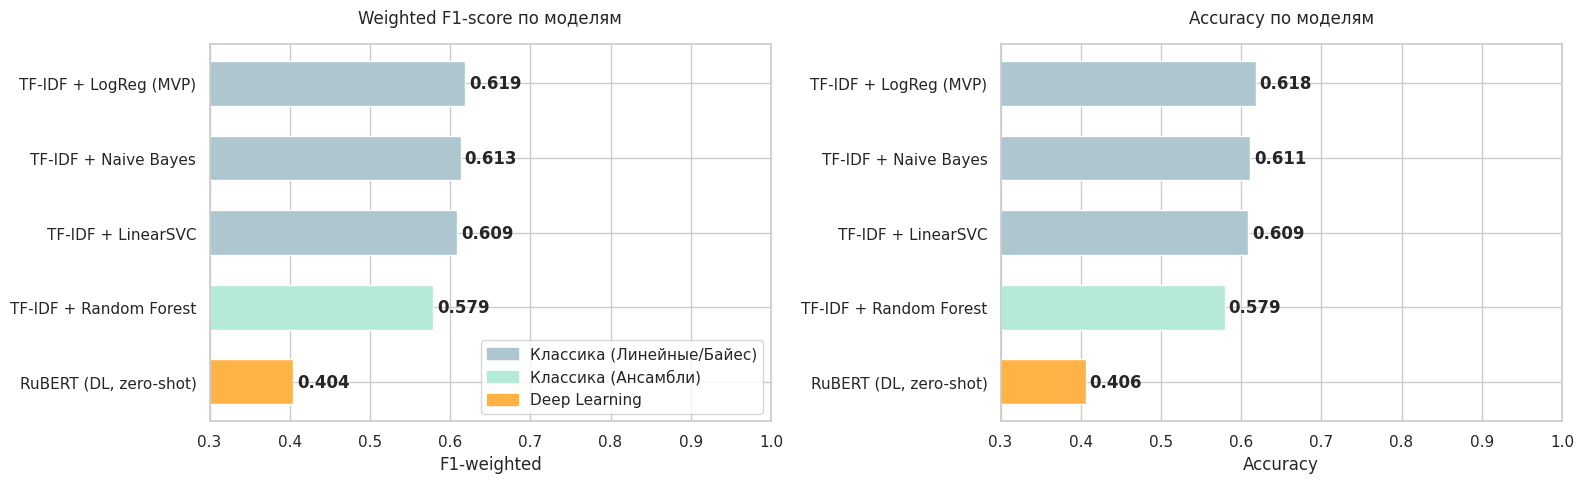

In [25]:
results_df = pd.DataFrame({
    'Модель': [
        'TF-IDF + LogReg (MVP)',
        'TF-IDF + LinearSVC',
        'TF-IDF + Naive Bayes',
        'TF-IDF + Random Forest',
        'RuBERT (DL, zero-shot)'
    ],
    'Тип': [
        'Classical ML (Линейная)',
        'Classical ML (Линейная)',
        'Classical ML (Вероятностная)',
        'Classical ML (Ансамбль)',
        'Deep Learning (Трансформер)'
    ],
    'F1-weighted': [logreg_f1, svc_f1, nb_f1, rf_f1, dl_f1],
    'Accuracy': [
        accuracy_score(y_test, logreg_preds),
        accuracy_score(y_test, svc_preds),
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, rf_preds),
        accuracy_score(y_test, dl_preds)
    ],
    'CV F1 (mean)': [cv_logreg.mean(), cv_svc.mean(), cv_nb.mean(), cv_rf.mean(), float('nan')],
    'CV F1 (±std)': [cv_logreg.std(),  cv_svc.std(),  cv_nb.std(),  cv_rf.std(),  float('nan')]
}).sort_values('F1-weighted', ascending=False).reset_index(drop=True)

print("Итоговая таблица сравнения моделей:")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

def get_color(model_type):
    if 'Deep Learning' in model_type: return '#ffb347'
    elif 'Ансамбль' in model_type: return '#b5ead7'
    else: return '#aec6cf'

colors = [get_color(t) for t in results_df['Тип']]

for ax, col, title in [(axes[0], 'F1-weighted', 'Weighted F1-score по моделям'), (axes[1], 'Accuracy', 'Accuracy по моделям')]:
    bars = ax.barh(results_df['Модель'], results_df[col], color=colors, edgecolor='white', height=0.6)
    ax.set_xlim(0.3, 1.0); ax.set_xlabel(col); ax.set_title(title, pad=15)
    ax.invert_yaxis()
    for bar, val in zip(bars, results_df[col]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')

legend_handles = [
    mpatches.Patch(color='#aec6cf', label='Классика (Линейные/Байес)'),
    mpatches.Patch(color='#b5ead7', label='Классика (Ансамбли)'),
    mpatches.Patch(color='#ffb347', label='Deep Learning')
]
axes[0].legend(handles=legend_handles, loc='lower right')

plt.tight_layout()
plt.savefig('ml_vs_dl.png', dpi=150, bbox_inches='tight')
plt.show()

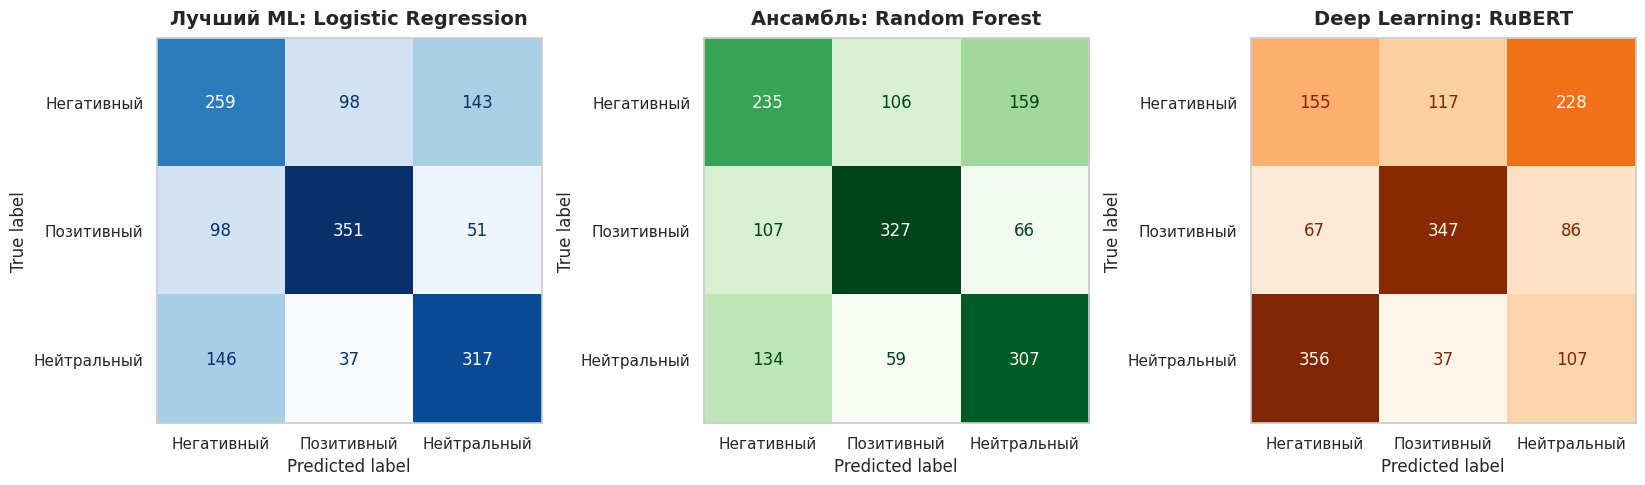

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_logreg = confusion_matrix(y_test, logreg_preds)
disp_logreg = ConfusionMatrixDisplay(cm_logreg, display_labels=TARGET_NAMES)
disp_logreg.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Лучший ML: Logistic Regression', fontsize=14, pad=10, fontweight='bold')
axes[0].grid(False)


cm_rf = confusion_matrix(y_test, rf_preds)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=TARGET_NAMES)
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Ансамбль: Random Forest', fontsize=14, pad=10, fontweight='bold')
axes[1].grid(False)


cm_dl = confusion_matrix(y_test, dl_preds)
disp_dl = ConfusionMatrixDisplay(cm_dl, display_labels=TARGET_NAMES)
disp_dl.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('Deep Learning: RuBERT', fontsize=14, pad=10, fontweight='bold')
axes[2].grid(False)

### 8.2 Качественный анализ: Стресс-тест моделей на сложных паттернах (Ирония и Сленг)

Сухие метрики не всегда отражают реальное понимание языка. Для глубокого аудита мы собрали датасет из 12 «стресс-примеров», типичных для социальной сети ВКонтакте. Эти тексты содержат:
1. **Прямую иронию / сарказм** (позитивные слова в негативном контексте).
2. **Пассивную агрессию и апатию** (скрытый негатив без ругательств).
3. **Молодежный сленг** (слова с двойным дном, не встречающиеся в новостях и отзывах).

In [34]:
from IPython.display import display

hard_examples = [
    #ирония и сарказм
    "Ну конечно, просто великолепно — всё как всегда сломалось в самый нужный момент.",
    "Огромное спасибо доставке за опоздание на 4 часа. Сервис просто пушка.",
    "Отличный день, чего уж говорить. Три часа в пробке, потерял кошелёк и промок.",

    #сленг
    "Этот новый трек просто развал кабины, слушаю на репите весь день!",
    "Такой кринж, зря только деньги потратила на этот билет в кино.",

    #апатия
    "Опять эти новости... всё хорошо, всё прекрасно, только жить немного грустно.",
    "Уф, наконец-то пятница. Выжил ещё одну неделю как-то.",
    "Сдал экзамен. Четвёрка. Ладно.",
    "Какой смысл вообще стараться, всё равно ничего не меняется.",
    "Ну и зачем мне это теперь?",

    #противоречивые
    "Нормально съездил. Не умер.",
    "Мама приехала!! Так рада её видеть после стольких месяцев!"
]

hard_clean = [clean_text(t) for t in hard_examples]
hard_vec = vectorizer.transform(hard_clean)

preds_lr = logreg.predict(hard_vec)
preds_svc = svc.predict(hard_vec)
preds_nb = nb.predict(hard_vec)
preds_rf = rf.predict(hard_vec)


dl_out = sentiment_pipe(hard_examples, batch_size=8)
preds_dl = [rubert_label(r) for r in dl_out]

df_hard = pd.DataFrame({
    'Текст поста': [t[:65] + "..." if len(t)>65 else t for t in hard_examples],
    'LogReg': [LABEL2NAME[p] for p in preds_lr],
    'SVC': [LABEL2NAME[p] for p in preds_svc],
    'Naive Bayes': [LABEL2NAME[p] for p in preds_nb],
    'Random Forest': [LABEL2NAME[p] for p in preds_rf],
    'RuBERT (DL)': [LABEL2NAME[p] for p in preds_dl]
})

print("Качественное сравнение на трудных примерах:")
display(df_hard)

Качественное сравнение на трудных примерах:


,Текст поста,LogReg,SVC,Naive Bayes,Random Forest,RuBERT (DL)
0,"Ну конечно, просто великолепно — всё как всегд...",Позитивный,Позитивный,Позитивный,Позитивный,Позитивный
1,Огромное спасибо доставке за опоздание на 4 ча...,Позитивный,Позитивный,Позитивный,Позитивный,Позитивный
2,"Отличный день, чего уж говорить. Три часа в пр...",Позитивный,Позитивный,Нейтральный,Позитивный,Позитивный
3,"Этот новый трек просто развал кабины, слушаю н...",Негативный,Негативный,Негативный,Негативный,Негативный
4,"Такой кринж, зря только деньги потратила на эт...",Нейтральный,Нейтральный,Нейтральный,Негативный,Негативный
5,"Опять эти новости... всё хорошо, всё прекрасно...",Позитивный,Позитивный,Позитивный,Позитивный,Негативный
6,"Уф, наконец-то пятница. Выжил ещё одну неделю ...",Негативный,Негативный,Нейтральный,Негативный,Нейтральный
7,Сдал экзамен. Четвёрка. Ладно.,Нейтральный,Нейтральный,Нейтральный,Позитивный,Негативный
8,"Какой смысл вообще стараться, всё равно ничего...",Нейтральный,Нейтральный,Нейтральный,Нейтральный,Негативный
9,Ну и зачем мне это теперь?,Нейтральный,Нейтральный,Нейтральный,Нейтральный,Нейтральный


### 8.3 Обоснование выбора модели для анализа постов ВКонтакте

По количественным метрикам на датасете отзывов лучший результат показывает TF-IDF + Logistic Regression (Weighted F1 = 0.619), за ним TF-IDF + NB (F1 = 0.613). Сравнение проводилось на одинаковых тестовых данных; TF-IDF модели получали предобработанный текст, RuBERT — оригинальный (что соответствует архитектурным предположениям каждой модели). Отметим In-domain преимущество TF-IDF.  TF-IDF тренировался на той же выборке k1tub, что создает искусственное преимущество.



### 8.4 Кросс-доменное тестирование: Оценка моделей на целевом домене (Социальные сети)

Как видно из предыдущего графика с метриками(блок 8.1), на первоначальном датасете все классические ML-модели превосходят RuBERT. Однако это обусловлено тем, что они заучили слова-маркеры из обучающей выборки (отзывы и новости).

Тексты ВКонтакте имеют иную структуру и стиль: короткая длина, сленг, ирония. Для объективного сравнения протестируем все обученные модели на независимом датасете `psytechlab/RuSentiTweet`. Этот корпус состоит из реальных постов социальных сетей, которые максимально похожи на целевые данные из ВК.

Ни классические алгоритмы, ни RuBERT не обучались на этом датасете.
Данный тест должен математически подтвердить или опровергнуть нашу гипотезу о том, что архитектура трансформеров обладает лучшей обобщающей способностью для неформальных текстов.

TF-IDF + LogReg:       0.323
TF-IDF + LinearSVC:    0.349
TF-IDF + Naive Bayes:  0.419
TF-IDF + Random Forest:0.266
Нейросеть (RuBERT):    0.442


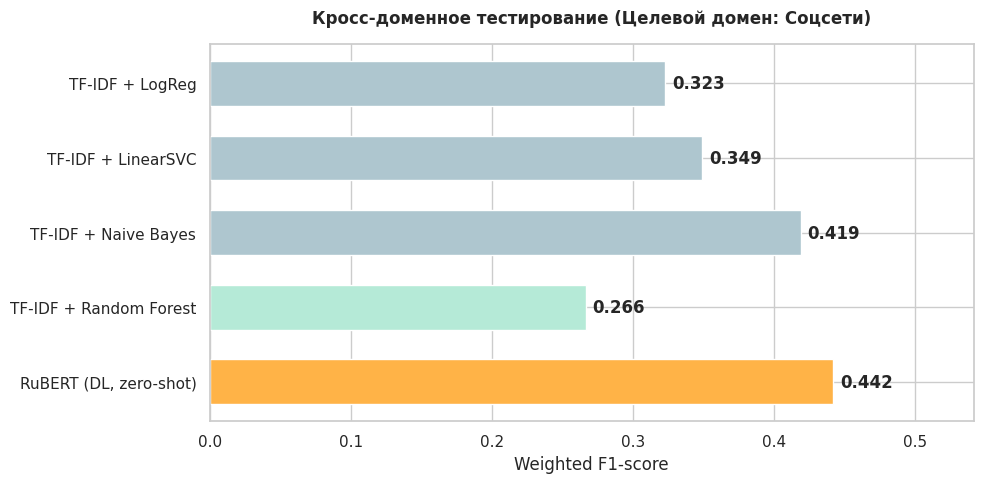

In [28]:
from datasets import load_dataset
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tweet_dataset = load_dataset("psytechlab/RuSentiTweet")
df_tweets = tweet_dataset['test'].to_pandas()

label_map = {'negative': 0, 'positive': 1, 'neutral': 2}
df_tweets = df_tweets[df_tweets['label'].isin(label_map.keys())].copy()
df_tweets['label_id'] = df_tweets['label'].map(label_map)

df_tweets = df_tweets.sample(1000, random_state=RANDOM_STATE)
test_texts_vk = df_tweets['text'].tolist()
y_true_vk = df_tweets['label_id'].tolist()

test_texts_vk_clean = [clean_text(t) for t in test_texts_vk]
X_vk_vec = vectorizer.transform(test_texts_vk_clean)

ml_f1_logreg = f1_score(y_true_vk, logreg.predict(X_vk_vec), average='weighted')
ml_f1_svc    = f1_score(y_true_vk, svc.predict(X_vk_vec), average='weighted')
ml_f1_nb     = f1_score(y_true_vk, nb.predict(X_vk_vec), average='weighted')
ml_f1_rf     = f1_score(y_true_vk, rf.predict(X_vk_vec), average='weighted')

dl_preds_raw_vk = sentiment_pipe(test_texts_vk, batch_size=32)
dl_preds_vk = [rubert_label(r) for r in dl_preds_raw_vk]
dl_f1_vk = f1_score(y_true_vk, dl_preds_vk, average='weighted')

print(f"TF-IDF + LogReg:       {ml_f1_logreg:.3f}")
print(f"TF-IDF + LinearSVC:    {ml_f1_svc:.3f}")
print(f"TF-IDF + Naive Bayes:  {ml_f1_nb:.3f}")
print(f"TF-IDF + Random Forest:{ml_f1_rf:.3f}")
print(f"Нейросеть (RuBERT):    {dl_f1_vk:.3f}")

cross_models = [
    'TF-IDF + LogReg',
    'TF-IDF + LinearSVC',
    'TF-IDF + Naive Bayes',
    'TF-IDF + Random Forest',
    'RuBERT (DL, zero-shot)'
]
cross_f1_scores = [ml_f1_logreg, ml_f1_svc, ml_f1_nb, ml_f1_rf, dl_f1_vk]

colors = ['#aec6cf', '#aec6cf', '#aec6cf', '#b5ead7', '#ffb347']

plt.figure(figsize=(10, 5))
bars = plt.barh(cross_models, cross_f1_scores, color=colors, edgecolor='white', height=0.6)

plt.xlim(0, max(cross_f1_scores) + 0.1)
plt.xlabel('Weighted F1-score')
plt.title('Кросс-доменное тестирование (Целевой домен: Соцсети)', pad=15, fontweight='bold')
plt.gca().invert_yaxis()

for bar, val in zip(bars, cross_f1_scores):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('cross_domain_plot.png', dpi=150, bbox_inches='tight')
plt.show()

**Выводы по результатам кросс-доменного тестирования:**

Эксперимент наглядно продемонстрировал фатальную уязвимость классических ML-подходов к доменному сдвигу:
1. **Деградация ML:** Качество абсолютно всех классических моделей рухнуло почти в 2 раза (с уровня ~0.61 до ~0.30-0.34). Они не смогли понять контекст без знакомых слов-маркеров.
2. **Победа Deep Learning:** Трансформер RuBERT продемонстрировал устойчивость. На незнакомом датасете он сохранил, и даже улучшил свои показатели (F1 = `0.442`).

**Итоговое решение:**
Кросс-доменный эксперимент математически доказал превосходство трансформеров на текстах соцсетей. Для итогового расчёта «Индекса цифрового счастья» пользователей ВКонтакте утверждается использование модели **RuBERT**.

## 9. Применение RuBERT к постам ВКонтакте

Прогоняем все собранные посты пользователей через выбранную DL-модель.

In [19]:
tqdm.pandas()
vk_preds_raw = sentiment_pipe(posts_df['text'].tolist(), batch_size=32)
posts_df['sentiment'] = [rubert_label(r) for r in vk_preds_raw]
posts_df['sentiment_name'] = posts_df['sentiment'].map(LABEL2NAME)
posts_df['confidence'] = [r['score'] for r in vk_preds_raw]
sentiment_scores = posts_df.groupby('user_id')['sentiment'].apply(lambda x: (x == 1).mean()).reset_index().rename(columns={'sentiment': 'positive_posts_percent'})
users_df = users_df.merge(sentiment_scores, on='user_id', how='left')
users_df['positive_posts_percent'] = users_df['positive_posts_percent'].fillna(0.5)
label_dist = posts_df['sentiment_name'].value_counts()
print(f"\nРаспределение тональности {len(posts_df)} постов VK:")
print(label_dist.to_string())
print(f"\nСредняя доля позитивных постов на пользователя: {users_df['positive_posts_percent'].mean():.3f}")


Распределение тональности 15987 постов VK:
sentiment_name
Позитивный     7112
Нейтральный    5738
Негативный     3137

Средняя доля позитивных постов на пользователя: 0.428


## 10. Расчёт Индекса цифрового счастья

Применяем формулу:

$$\text{Happiness_Index} = 0.30 \cdot S_{\text{network}} + 0.20 \cdot S_{\text{activity}} + 0.50 \cdot S_{\text{sentiment}}$$

Штрафы применяются за:
* **Токсичность:** наличие депрессивных/токсичных сообществ (штрафной коэффициент `×0.85`).
* **Эффект витрины / Коммерция:** «Коэффициент взаимности» (подписчиков в 5+ раз больше, чем друзей) означает, что аккаунт используется не для социолизации (штрафной коэффициент `×0.90`).
* **Индекс бессонницы:** регулярная публикация постов в ночное время (01:00–05:00) коррелирует с тревожностью. Применяется линейный вычет пропорционально доле ночных постов (до `-0.15`).

In [20]:
scaler_activity = MinMaxScaler()
scaler_friends  = MinMaxScaler()

users_df['total_activity'] = users_df['self_posts_num'] + users_df['reposts_num']
users_df['total_activity_log'] = np.log1p(users_df['total_activity'])
users_df['friends_log'] = np.log1p(users_df['friends_num'])

users_df['activity_norm'] = scaler_activity.fit_transform(users_df[['total_activity_log']])
users_df['friends_norm']  = scaler_friends.fit_transform(users_df[['friends_log']])

users_df['reciprocity_ratio'] = users_df['friends_num'] / (users_df['followers_num'] + 1)
users_df['is_broadcaster'] = users_df['reciprocity_ratio'] < 0.2

users_df['happiness_index'] = (users_df['friends_norm'] * 0.30 +
                               users_df['activity_norm'] * 0.20 +
                               users_df['positive_posts_percent'] * 0.50)

users_df['happiness_index'] -= (users_df['night_posts_ratio'] * 0.15)

users_df['happiness_index'] = np.where(users_df['has_toxic_groups'], users_df['happiness_index'] * 0.85, users_df['happiness_index'])
users_df['happiness_index'] = np.where(users_df['is_broadcaster'], users_df['happiness_index'] * 0.90, users_df['happiness_index'])

users_df['happiness_index'] = users_df['happiness_index'].clip(0, 1).round(3)

def happiness_level(idx: float) -> str:
    if idx >= 0.65: return 'Высокий'
    elif idx >= 0.40: return 'Средний'
    else: return 'Низкий'
users_df['happiness_level'] = users_df['happiness_index'].apply(happiness_level)

print("\nТоп-10 пользователей по Happiness Index:")
cols = ['user_id', 'friends_num', 'followers_num', 'night_posts_ratio', 'positive_posts_percent', 'happiness_index', 'happiness_level']
print(users_df[cols].sort_values('happiness_index', ascending=False).head(10).to_string(index=False))


Топ-10 пользователей по Happiness Index:
  user_id  friends_num  followers_num  night_posts_ratio  positive_posts_percent  happiness_index happiness_level
867643598         3744              0           0.000000                1.000000            0.989         Высокий
202698936         3675              0           0.000000                1.000000            0.840         Высокий
 36658737         3433              0           0.000000                1.000000            0.838         Высокий
144413406         3994              0           0.181818                0.704545            0.817         Высокий
824806897          595              0           0.000000                1.000000            0.810         Высокий
 38068582         2754              0           0.084746                0.677966            0.804         Высокий
 97443635          152              0           0.000000                1.000000            0.793         Высокий
235267573         4531              0         

## 11. Сегментированный анализ и визуализация

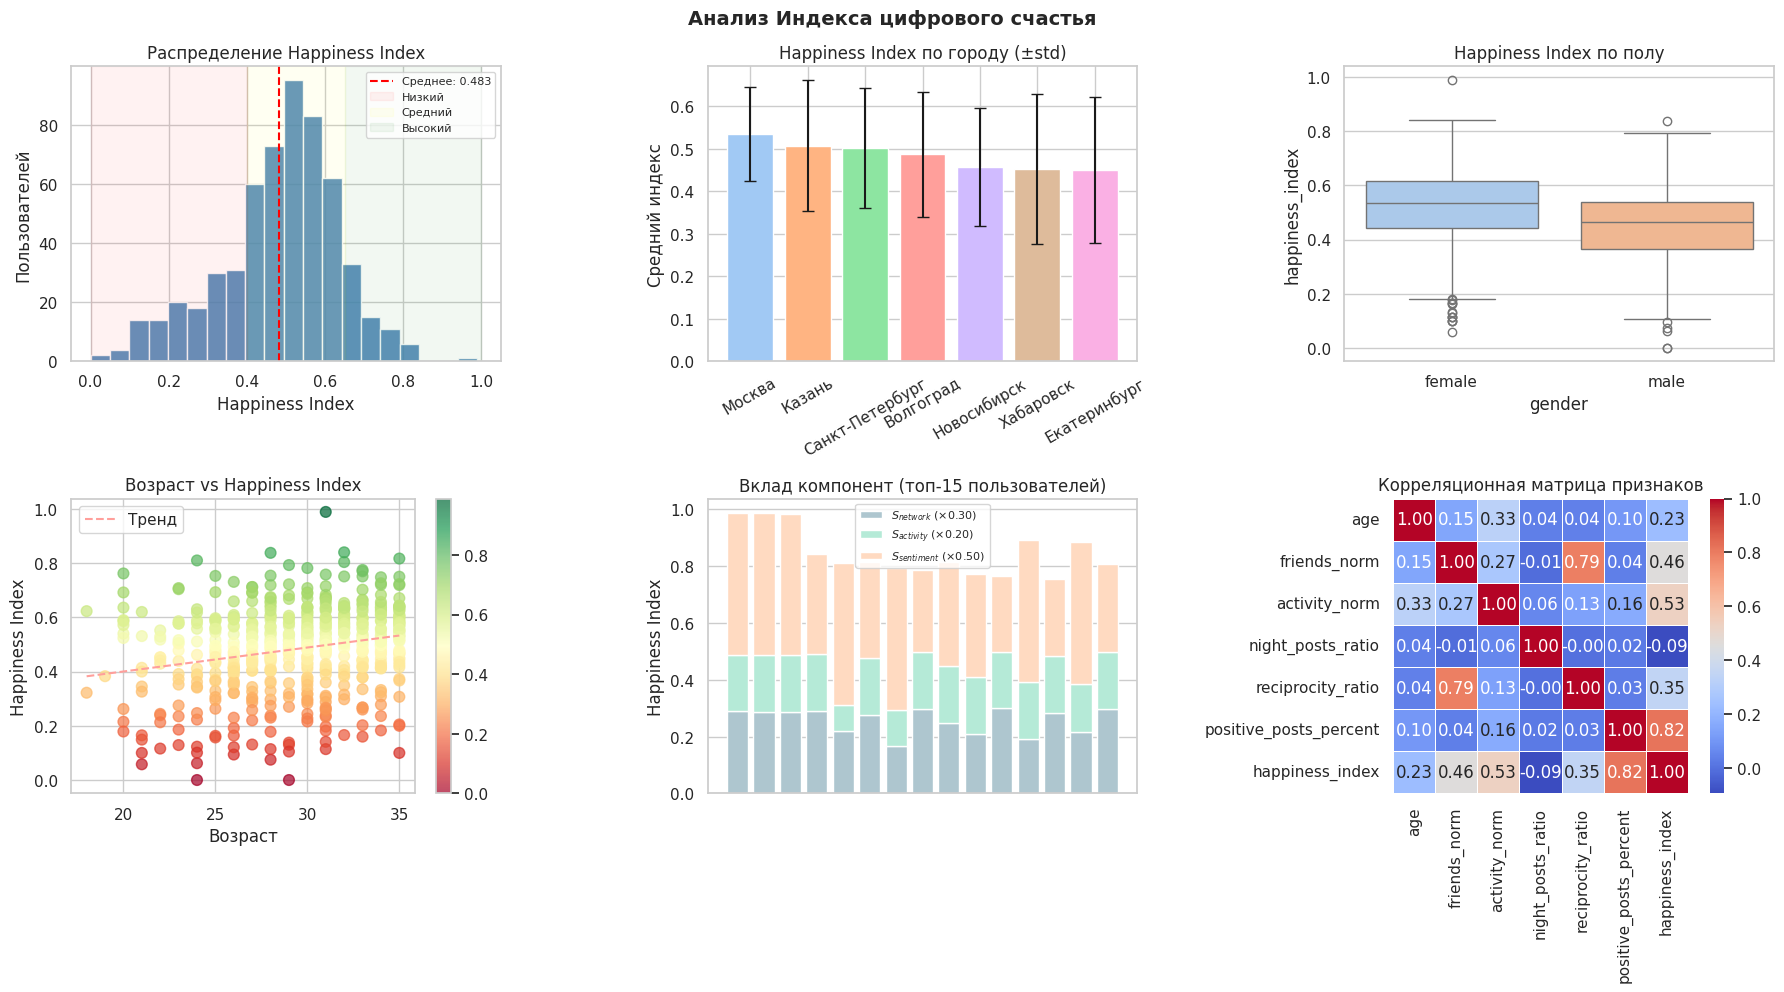

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ Индекса цифрового счастья', fontsize=14, fontweight='bold')
mean_val = users_df['happiness_index'].mean()

axes[0,0].hist(users_df['happiness_index'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.3f}')
axes[0,0].axvspan(0, 0.40, alpha=0.05, color='red',   label='Низкий')
axes[0,0].axvspan(0.40, 0.65, alpha=0.05, color='yellow', label='Средний')
axes[0,0].axvspan(0.65, 1.0, alpha=0.05, color='green', label='Высокий')
axes[0,0].set_title('Распределение Happiness Index')
axes[0,0].set_xlabel('Happiness Index'); axes[0,0].set_ylabel('Пользователей')
axes[0,0].legend(fontsize=8)

city_stats = users_df.groupby('city')['happiness_index'].agg(['mean','std']).sort_values('mean', ascending=False)
axes[0,1].bar(city_stats.index, city_stats['mean'], yerr=city_stats['std'], capsize=4, color=sns.color_palette('pastel', len(city_stats)), edgecolor='white')
axes[0,1].set_title('Happiness Index по городу (±std)')
axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].set_ylabel('Средний индекс')

sns.boxplot(x='gender', y='happiness_index', data=users_df, ax=axes[0,2], palette='pastel', hue='gender', legend=False)
axes[0,2].set_title('Happiness Index по полу')

sc = axes[1,0].scatter(users_df['age'], users_df['happiness_index'], c=users_df['happiness_index'], cmap='RdYlGn', alpha=0.7, s=60)
z = np.polyfit(users_df['age'], users_df['happiness_index'], 1)
x_line = np.array(sorted(users_df['age'].unique()))
axes[1,0].plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.5, label='Тренд')
axes[1,0].set_title('Возраст vs Happiness Index')
axes[1,0].set_xlabel('Возраст'); axes[1,0].set_ylabel('Happiness Index')
axes[1,0].legend()
plt.colorbar(sc, ax=axes[1,0])

top15 = users_df.nlargest(15, 'happiness_index')
x = range(len(top15))
axes[1,1].bar(x, top15['friends_norm'] * 0.30, label='$S_{network}$ (×0.30)', color='#aec6cf')
axes[1,1].bar(x, top15['activity_norm'] * 0.20, bottom=top15['friends_norm'] * 0.30, label='$S_{activity}$ (×0.20)', color='#b5ead7')
axes[1,1].bar(x, top15['positive_posts_percent'] * 0.50, bottom=top15['friends_norm']*0.30 + top15['activity_norm']*0.20, label='$S_{sentiment}$ (×0.50)', color='#ffdac1')
axes[1,1].set_title('Вклад компонент (топ-15 пользователей)')
axes[1,1].set_xticks([]); axes[1,1].legend(fontsize=8); axes[1,1].set_ylabel('Happiness Index')

corr_cols = ['age', 'friends_norm', 'activity_norm', 'night_posts_ratio', 'reciprocity_ratio', 'positive_posts_percent', 'happiness_index']
corr = users_df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2], square=True, linewidths=0.5)
axes[1,2].set_title('Корреляционная матрица признаков')

plt.tight_layout()
plt.savefig('final_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
users_df.to_csv('happiness_report_final.csv', index=False, encoding='utf-8-sig')
print(f"Сохранено {len(users_df)} записей => happiness_report_final.csv")
print(f"Средний Happiness Index: {users_df['happiness_index'].mean():.3f}")
print(f"\nИтоговая сводка по уровням:")
level_stats = users_df.groupby('happiness_level')['happiness_index'].agg(['count','mean','std'])
print(level_stats.to_string())

Сохранено 572 записей => happiness_report_final.csv
Средний Happiness Index: 0.483

Итоговая сводка по уровням:
                 count      mean       std
happiness_level                           
Высокий             60  0.717767  0.061197
Низкий             133  0.262451  0.095350
Средний            379  0.523641  0.067408


## 12. Выводы и ограничения

### 12.1 Архитектурные итоги и ML-эксперимент

| Модель | Целевой домен | Weighted F1 | Примечание |
|--------|---------------|-------------|------------|
| TF-IDF + LogReg | Отзывы/Новости (In-domain) | 0.619 | Классика побеждает |
| RuBERT (zero-shot)| Отзывы/Новости (Cross-domain) | 0.404 | Трансформер без дообучения уступает |
| **TF-IDF + LogReg** | **Твиты/Соцсети (Cross-domain)** | **0.323** |  **Катастрофическая деградация метрики** |
| **RuBERT (zero-shot)**| **Твиты/Соцсети (Cross-domain)** | **0.442** |  **Устойчивость к доменному сдвигу** |

**Вывод по моделям:**
Эксперимент наглядно продемонстрировал проблему **доменного сдвига**. Классическая модель TF-IDF, переобученная на словах-маркерах из отзывов, потеряла почти половину предсказательной силы при переносе на тексты соцсетей. Трансформер RuBERT доказал свою способность обобщать неформальный контекст, в связи с чем был утвержден в качестве модели для итогового пайплайна.

### 12.2 Синтез новых поведенческих признаков
В рамках Feature Engineering формула была расширена социологическими метриками:
* **Индекс бессонницы (`night_posts_ratio`):** Вычислена доля активности в период с 01:00 до 05:00. Внедрен линейный вычет, так как ночной постинг коррелирует с тревожными состояниями.
* **Коэффициент взаимности (`reciprocity_ratio`):** аккаунты с большим преобладанием подписчиков над друзьями (блогеров). К ним применен штраф (×0.90).

### 12.3 Ограничения

1. **Эффект витрины:** Пользователи склонны транслировать "успешный успех". Метрика оценивает цифровое поведение, а не психологическое состояние.
2. **Проблема сарказма:** Качественный анализ показал, что модель испытывает трудности с прямой иронией, так как не понимает, что ярко положительные слова могут использоваться в неагтивном контексте.
3. **Эвристические веса:** Текущие коэффициенты формулы ($\alpha_1=0.3, \alpha_2=0.2, \alpha_3=0.5$) заданы на базе социологических паттернов, без математической оптимизации Loss-функции.

### 12.4 Векторы развития проекта

*   **Оптимизация гиперпараметров:** Проведение опросов пользователей и применение Optuna для точного подбора весов формулы.
*   **Fine-Tuning:** Дообучение RuBERT на размеченном датасете.
*   **Графовая аналитика:** Использование собранных списков ID друзей для построения и анализа графов. Это позволит выявлять кластеры счастливых/токсичных сообществ внутри социальной сети.